In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/original_data_train_EMA.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df

,timestamp,devID,soil,rain,temp,humi,geo,lat,lng,iso_score,...,rain_ema_720min,rain_ema_1440min,geo_ema_2min,geo_ema_4min,geo_ema_6min,geo_ema_8min,soil_ema_240min,soil_ema_480min,soil_ema_720min,soil_ema_960min
0,2025-11-01 07:27:07.061,104,1.597111,-1.0,0.000000,0.000000,0.000000,0.000000,0.000000,-0.082559,...,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,1.597111,1.597111,1.597111,1.597111
1,2025-11-02 06:53:31.255,105,0.000000,-1.0,34.700001,66.300003,0.000000,0.000000,0.000000,0.018855,...,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2025-11-02 06:54:45.593,105,1.604702,-1.0,34.900002,64.199997,0.000000,-1.000000,-1.000000,0.017623,...,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.803787,0.803069,0.802830,0.802710
3,2025-11-02 06:55:30.524,105,1.604702,-1.0,35.200001,64.900002,0.000000,-1.000000,-1.000000,0.013344,...,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,1.071462,1.070632,1.070355,1.070217
4,2025-11-02 06:56:19.973,105,1.604702,-1.0,35.200001,63.650002,0.000000,-1.000000,-1.000000,0.010334,...,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,1.205274,1.204401,1.204109,1.203964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46125,2025-11-10 23:03:53.403,109,34.700001,0.0,22.600000,95.699997,0.502969,8.868613,99.749542,0.034526,...,0.213832,0.202033,0.516852,0.794005,1.018292,1.205940,34.017515,33.001000,32.585888,32.434765
46126,2025-11-10 23:04:38.475,109,34.700001,0.0,22.600000,95.699997,0.458977,8.868613,99.749542,0.036213,...,0.213653,0.201942,0.503590,0.753124,0.971813,1.158884,34.019097,33.003050,32.587662,32.436240
46127,2025-11-10 23:05:23.550,109,34.700001,0.0,22.600000,95.549999,0.441460,8.868616,99.749542,0.033801,...,0.213474,0.201851,0.489352,0.715092,0.927739,1.113689,34.020675,33.005097,32.589433,32.437714
46128,2025-11-10 23:06:08.621,109,34.700001,0.0,22.700001,95.199997,0.431964,8.868616,99.749542,0.033801,...,0.213295,0.201760,0.476200,0.680542,0.886539,1.070741,34.022250,33.007142,32.591203,32.439186


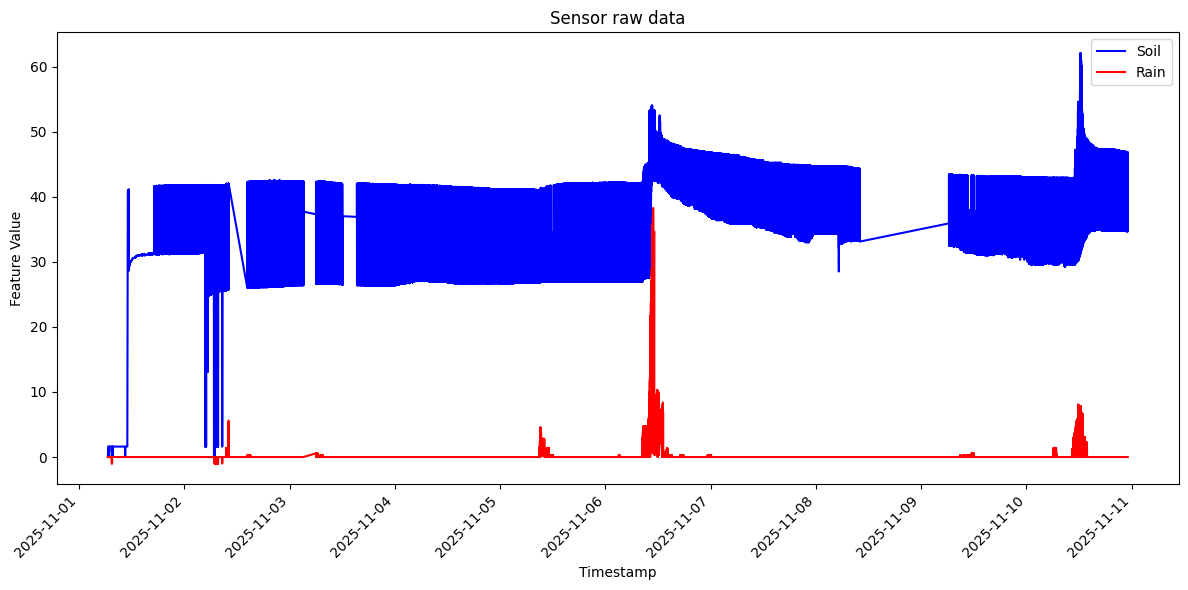

In [3]:
features = ['soil', 'rain']
colors = ['blue', 'red', 'red', 'black', 'orange']

plt.figure(figsize=(12, 6))

for i, feature in enumerate(features):
    sns.lineplot(data=df, x='timestamp', y=feature, label=feature.capitalize(), color=colors[i])

plt.title('Sensor raw data')
plt.xlabel('Timestamp')
plt.ylabel('Feature Value')
plt.xticks(rotation=45, ha='right') # Rotate labels and align them to the right
plt.legend()
plt.tight_layout()
plt.show()

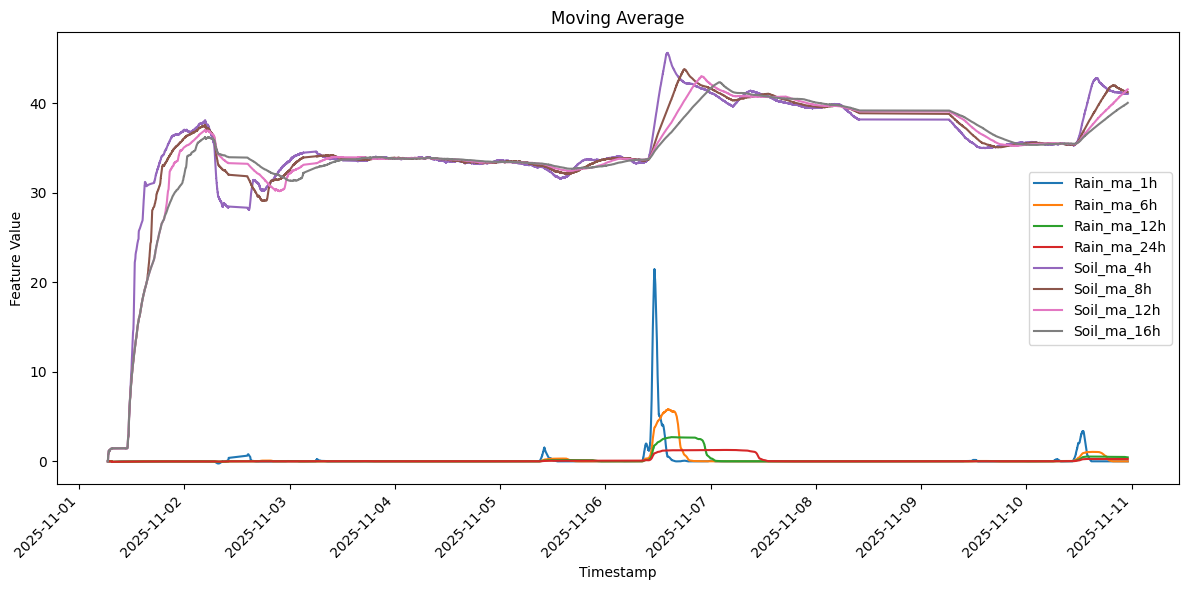

In [4]:
features = ['rain_ma_1h', 'rain_ma_6h','rain_ma_12h','rain_ma_24h', 'soil_ma_4h','soil_ma_8h','soil_ma_12h','soil_ma_16h']
palette = sns.color_palette("tab10", n_colors=len(features))

plt.figure(figsize=(12, 6))

for i, feature in enumerate(features):
    sns.lineplot(data=df, x='timestamp', y=feature, label=feature.capitalize(), color=palette[i])

plt.title('Moving Average')
plt.xlabel('Timestamp')
plt.ylabel('Feature Value')
plt.xticks(rotation=45, ha='right') # Rotate labels and align them to the right
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Define the start and end dates for filtering
start_date = '2025-11-06'
en_date = '2025-11-07'

# Filter the DataFrame for the specified date range
df22 = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= en_date)]

# Display the first 5 rows of the new DataFrame
display(df22.head())

,timestamp,devID,soil,rain,temp,humi,geo,lat,lng,iso_score,...,rain_ema_720min,rain_ema_1440min,geo_ema_2min,geo_ema_4min,geo_ema_6min,geo_ema_8min,soil_ema_240min,soil_ema_480min,soil_ema_720min,soil_ema_960min
10814,2025-11-06 00:00:02.259,106,35.200001,0.0,24.200001,95.099998,0.519564,8.88665,99.784546,0.034007,...,0.084127,0.073739,4.735739,4.121351,3.883128,3.881175,35.025924,34.981735,35.054818,35.133038
10815,2025-11-06 00:00:47.319,106,35.200001,0.0,24.200001,94.950001,0.538823,8.88665,99.784546,0.034007,...,0.084064,0.073708,3.774049,3.684227,3.605234,3.670633,35.026304,34.981975,35.054927,35.133077
10816,2025-11-06 00:01:32.383,106,35.200001,0.0,24.200001,94.699997,10.642339,8.88665,99.784546,0.065120,...,0.084001,0.073676,5.347922,4.533243,4.189989,4.109800,35.026683,34.982214,35.055035,35.133116
10817,2025-11-06 00:02:17.460,106,35.200001,0.0,24.200001,94.649998,5.554532,8.88665,99.784546,0.061132,...,0.083938,0.073644,5.395271,4.657865,4.303381,4.200811,35.027061,34.982454,35.055144,35.133155
10818,2025-11-06 00:03:02.473,106,35.200001,0.0,24.200001,94.599998,0.466725,8.88665,99.784546,0.035696,...,0.083875,0.073613,4.266039,4.146504,3.984584,3.965598,35.027438,34.982693,35.055252,35.133194


In [6]:
df22

,timestamp,devID,soil,rain,temp,humi,geo,lat,lng,iso_score,...,rain_ema_720min,rain_ema_1440min,geo_ema_2min,geo_ema_4min,geo_ema_6min,geo_ema_8min,soil_ema_240min,soil_ema_480min,soil_ema_720min,soil_ema_960min
10814,2025-11-06 00:00:02.259,106,35.200001,0.0000,24.200001,95.099998,0.519564,8.886650,99.784546,0.034007,...,0.084127,0.073739,4.735739,4.121351,3.883128,3.881175,35.025924,34.981735,35.054818,35.133038
10815,2025-11-06 00:00:47.319,106,35.200001,0.0000,24.200001,94.950001,0.538823,8.886650,99.784546,0.034007,...,0.084064,0.073708,3.774049,3.684227,3.605234,3.670633,35.026304,34.981975,35.054927,35.133077
10816,2025-11-06 00:01:32.383,106,35.200001,0.0000,24.200001,94.699997,10.642339,8.886650,99.784546,0.065120,...,0.084001,0.073676,5.347922,4.533243,4.189989,4.109800,35.026683,34.982214,35.055035,35.133116
10817,2025-11-06 00:02:17.460,106,35.200001,0.0000,24.200001,94.649998,5.554532,8.886650,99.784546,0.061132,...,0.083938,0.073644,5.395271,4.657865,4.303381,4.200811,35.027061,34.982454,35.055144,35.133155
10818,2025-11-06 00:03:02.473,106,35.200001,0.0000,24.200001,94.599998,0.466725,8.886650,99.784546,0.035696,...,0.083875,0.073613,4.266039,4.146504,3.984584,3.965598,35.027438,34.982693,35.055252,35.133194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40415,2025-11-06 23:56:23.283,109,36.900002,0.2794,26.000000,84.199997,0.343291,8.868578,99.749557,0.048847,...,0.866243,0.651318,1.325305,1.964544,2.254607,2.403440,37.502675,35.164661,33.388331,32.219161
40416,2025-11-06 23:57:08.351,109,36.900002,0.2794,26.000000,82.000000,0.981742,8.868578,99.749557,0.057205,...,0.865772,0.651163,1.246575,1.844620,2.148825,2.313845,37.501221,35.166762,33.391150,32.221988
40417,2025-11-06 23:57:53.424,109,36.900002,0.2794,26.050000,82.599998,0.712443,8.868578,99.749557,0.055092,...,0.865301,0.651008,1.124166,1.706463,2.029452,2.212926,37.499771,35.168860,33.393967,32.224812
40418,2025-11-06 23:58:38.447,109,36.900002,0.2794,26.100000,83.199997,0.443144,8.868578,99.749557,0.051092,...,0.864831,0.650854,0.968121,1.552318,1.897628,2.101403,37.498324,35.170955,33.396781,32.227634


In [7]:
# Remove rows where 'geo' is less than 0 and greater than 30
df = df[(df['geo'] >= 0) & (df['geo'] <= 30)]

# Display the first 5 rows of the updated DataFrame
display(df.head())

,timestamp,devID,soil,rain,temp,humi,geo,lat,lng,iso_score,...,rain_ema_720min,rain_ema_1440min,geo_ema_2min,geo_ema_4min,geo_ema_6min,geo_ema_8min,soil_ema_240min,soil_ema_480min,soil_ema_720min,soil_ema_960min
0,2025-11-01 07:27:07.061,104,1.597111,-1.0,0.000000,0.000000,0.0,0.0,0.0,-0.082559,...,-1.0,-1.0,0.0,0.0,0.0,0.0,1.597111,1.597111,1.597111,1.597111
1,2025-11-02 06:53:31.255,105,0.000000,-1.0,34.700001,66.300003,0.0,0.0,0.0,0.018855,...,-1.0,-1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
2,2025-11-02 06:54:45.593,105,1.604702,-1.0,34.900002,64.199997,0.0,-1.0,-1.0,0.017623,...,-1.0,-1.0,0.0,0.0,0.0,0.0,0.803787,0.803069,0.802830,0.802710
3,2025-11-02 06:55:30.524,105,1.604702,-1.0,35.200001,64.900002,0.0,-1.0,-1.0,0.013344,...,-1.0,-1.0,0.0,0.0,0.0,0.0,1.071462,1.070632,1.070355,1.070217
4,2025-11-02 06:56:19.973,105,1.604702,-1.0,35.200001,63.650002,0.0,-1.0,-1.0,0.010334,...,-1.0,-1.0,0.0,0.0,0.0,0.0,1.205274,1.204401,1.204109,1.203964


In [8]:
print(df['timestamp'].dtype)

datetime64[ns]


In [9]:
ma_features = ['geo_ma_2min', 'geo_ma_4min', 'geo_ma_6min', 'geo_ma_8min']

# Create a boolean mask where all specified moving average features are within the [0, 30] range
mask = ((df[ma_features] >= 0) & (df[ma_features] <= 30)).all(axis=1)

# Apply the mask to filter the DataFrame
df = df[mask]

# Display the first 5 rows of the updated DataFrame
display(df.head())

,timestamp,devID,soil,rain,temp,humi,geo,lat,lng,iso_score,...,rain_ema_720min,rain_ema_1440min,geo_ema_2min,geo_ema_4min,geo_ema_6min,geo_ema_8min,soil_ema_240min,soil_ema_480min,soil_ema_720min,soil_ema_960min
0,2025-11-01 07:27:07.061,104,1.597111,-1.0,0.000000,0.000000,0.0,0.0,0.0,-0.082559,...,-1.0,-1.0,0.0,0.0,0.0,0.0,1.597111,1.597111,1.597111,1.597111
1,2025-11-02 06:53:31.255,105,0.000000,-1.0,34.700001,66.300003,0.0,0.0,0.0,0.018855,...,-1.0,-1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
2,2025-11-02 06:54:45.593,105,1.604702,-1.0,34.900002,64.199997,0.0,-1.0,-1.0,0.017623,...,-1.0,-1.0,0.0,0.0,0.0,0.0,0.803787,0.803069,0.802830,0.802710
3,2025-11-02 06:55:30.524,105,1.604702,-1.0,35.200001,64.900002,0.0,-1.0,-1.0,0.013344,...,-1.0,-1.0,0.0,0.0,0.0,0.0,1.071462,1.070632,1.070355,1.070217
4,2025-11-02 06:56:19.973,105,1.604702,-1.0,35.200001,63.650002,0.0,-1.0,-1.0,0.010334,...,-1.0,-1.0,0.0,0.0,0.0,0.0,1.205274,1.204401,1.204109,1.203964


In [10]:
# Define the start and end dates for filtering
start_date = '2025-11-01'
en_date = '2025-11-07'

# Filter the DataFrame for the specified date range, devID, and geo values
d = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= en_date) & (df['devID'] == 108) & (df['geo'] >= 0) & (df['geo'] <= 35)]

# Display the first 5 rows of the new DataFrame
d

,timestamp,devID,soil,rain,temp,humi,geo,lat,lng,iso_score,...,rain_ema_720min,rain_ema_1440min,geo_ema_2min,geo_ema_4min,geo_ema_6min,geo_ema_8min,soil_ema_240min,soil_ema_480min,soil_ema_720min,soil_ema_960min
24124,2025-11-01 06:33:49.988,108,0.000000,0.0,34.000000,66.500000,0.000000,0.000000,0.000000,0.029171,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
24125,2025-11-01 06:34:28.395,108,0.000000,0.0,34.000000,66.500000,0.000000,0.000000,0.000000,0.029171,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
24126,2025-11-01 06:35:13.489,108,0.798555,0.0,34.049999,66.650002,0.000000,-1.000000,-1.000000,0.029812,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.266735,0.266460,0.266368,0.266322
24127,2025-11-01 06:35:33.224,108,0.000000,0.0,34.200001,67.900002,0.000000,0.000000,0.000000,0.032640,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.199900,0.199770,0.199726,0.199704
24128,2025-11-01 06:36:11.416,108,0.000000,0.0,34.200001,67.900002,0.000000,0.000000,0.000000,0.032640,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.159789,0.159750,0.159737,0.159731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29878,2025-11-06 23:54:09.816,108,46.599998,0.0,24.000000,98.400002,0.487596,8.866799,99.754425,0.043029,...,0.643877,0.491529,6.510992,8.163093,8.274100,8.179988,46.897110,45.962245,45.143212,44.552472
29879,2025-11-06 23:54:54.832,108,46.599998,0.0,24.000000,98.400002,0.411630,8.866799,99.754425,0.042682,...,0.643035,0.491194,4.629916,6.762580,7.282461,7.433755,46.896042,45.963467,45.145117,44.554507
29880,2025-11-06 23:57:09.955,108,46.599998,0.0,24.100000,98.500000,11.754997,8.866799,99.754425,0.083962,...,0.642194,0.490859,7.496425,7.814415,7.911292,7.885545,46.894974,45.964689,45.147021,44.556542
29881,2025-11-06 23:58:40.049,108,46.599998,0.0,24.100000,98.400002,7.124174,8.866798,99.754433,0.078035,...,0.641353,0.490524,7.346152,7.666262,7.798520,7.804530,46.893910,45.965908,45.148923,44.558575


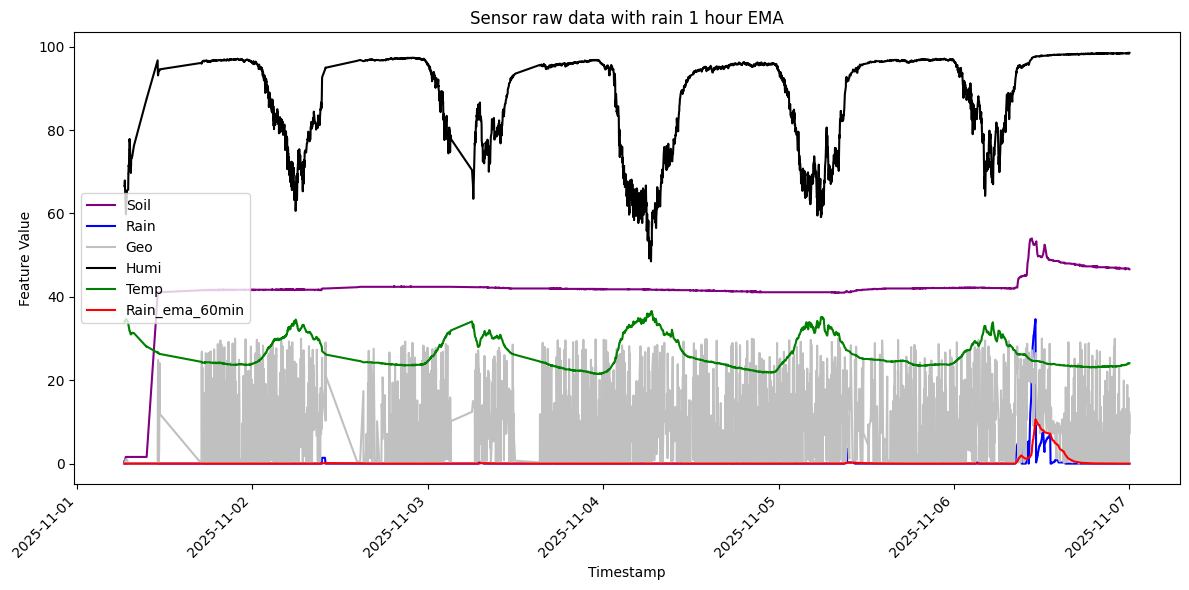

In [15]:
features = ['soil', 'rain','geo','humi','temp','rain_ema_60min']
colors = ['purple', 'blue', 'silver', 'black', 'green','red']

plt.figure(figsize=(12, 6))

for i, feature in enumerate(features):
    sns.lineplot(data=d, x='timestamp', y=feature, label=feature.capitalize(), color=colors[i])

plt.title('Sensor raw data with rain 1 hour EMA')
plt.xlabel('Timestamp')
plt.ylabel('Feature Value')
plt.xticks(rotation=45, ha='right') # Rotate labels and align them to the right
plt.legend()
plt.tight_layout()
plt.show()

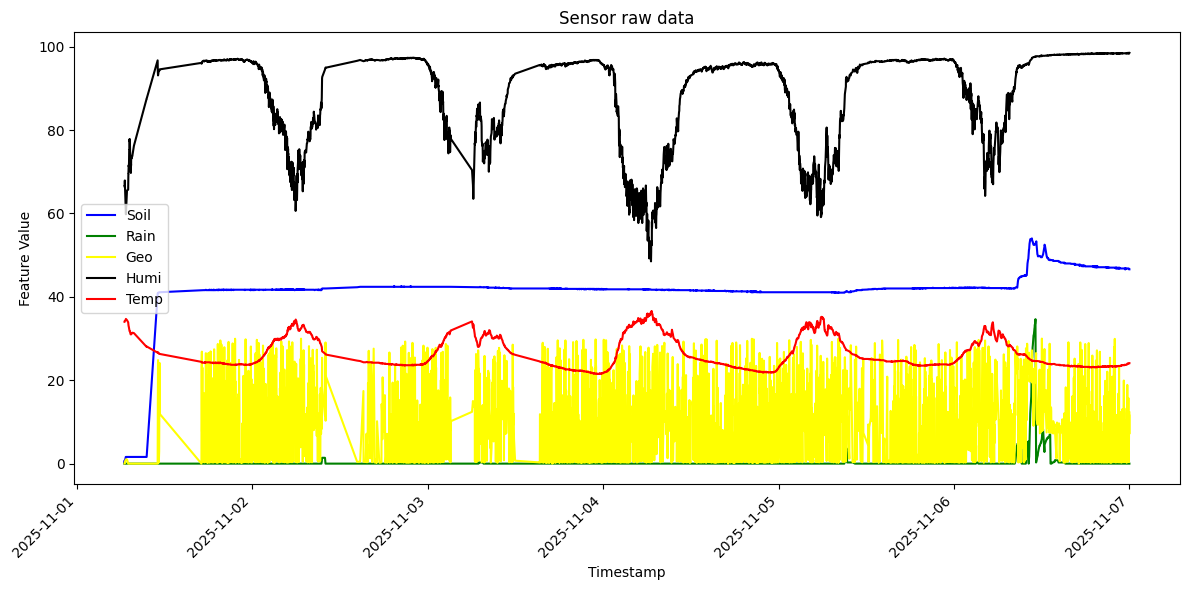

In [13]:
features = ['soil', 'rain','geo','humi','temp']
colors = ['blue', 'green', 'yellow', 'black', 'red']

plt.figure(figsize=(12, 6))

for i, feature in enumerate(features):
    sns.lineplot(data=d, x='timestamp', y=feature, label=feature.capitalize(), color=colors[i])

plt.title('Sensor raw data')
plt.xlabel('Timestamp')
plt.ylabel('Feature Value')
plt.xticks(rotation=45, ha='right') # Rotate labels and align them to the right
plt.legend()
plt.tight_layout()
plt.show()

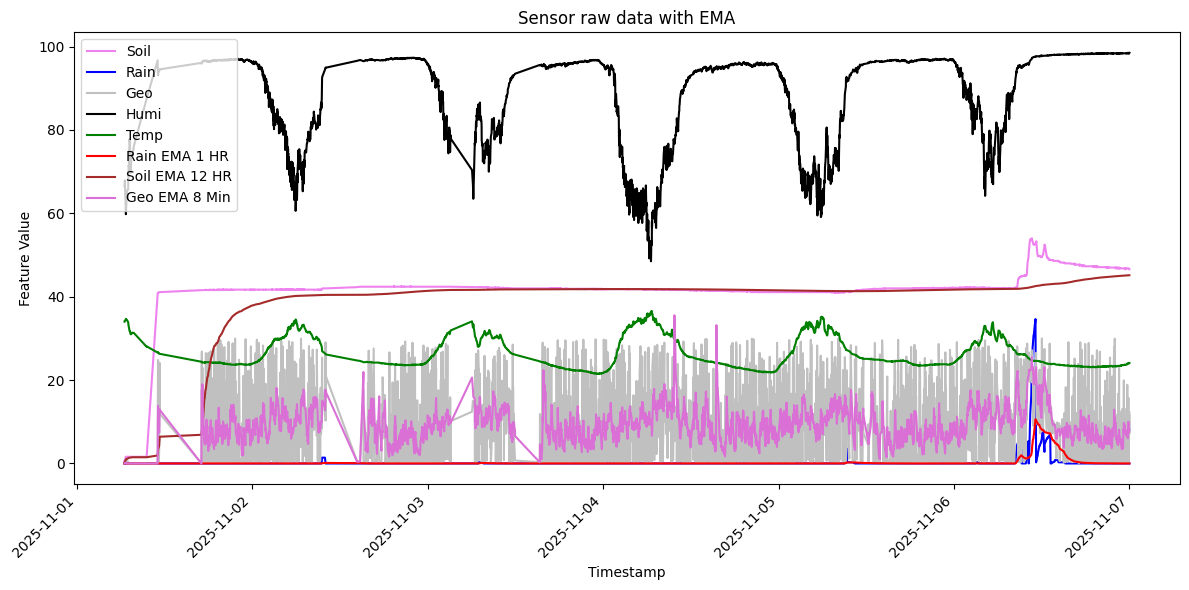

In [18]:
features = ['soil', 'rain','geo','humi','temp','rain_ema_60min','soil_ema_720min','geo_ema_8min']
colors = ['violet', 'blue', 'silver', 'black', 'green','red','brown','orchid']

plt.figure(figsize=(12, 6))

# Define custom labels for specific features
custom_labels = {
    'rain_ema_60min': 'Rain EMA 1 HR',
    'soil_ema_720min': 'Soil EMA 12 HR',
    'geo_ema_8min': 'Geo EMA 8 Min'
}

for i, feature in enumerate(features):
    # Use custom label if available, otherwise apply default formatting
    formatted_label = custom_labels.get(feature, feature.replace('_', ' ').title().replace('Ma', 'MA'))
    sns.lineplot(data=d, x='timestamp', y=feature, label=formatted_label, color=colors[i])

plt.title('Sensor raw data with EMA')
plt.xlabel('Timestamp')
plt.ylabel('Feature Value')
plt.xticks(rotation=45, ha='right') # Rotate labels and align them to the right
plt.legend()
plt.tight_layout()
plt.show()